# Redundancy in hidden Transformer layers - vision model similarity

*Commands to reproduce audio model results regarding CKA and cosine similarity of intermediate layers:*

```
TODO: add commands
```

In [13]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
plt.style.use('ggplot')

cmaps = {
    'cosine': 'RdGy',
    'cka': 'BrBG',
    'jacobian': 'RdBu',
}

EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments")

In [15]:
def plot_similarity_matrices(experiments):
    for exp_name, exp_path in experiments.items():
        results = torch.load(exp_path)

        for sim_type in ['cosine', 'cka']:
            similarities = results[f'all-{sim_type}-similarities']
            _mean, _std = torch.stack(similarities).mean(dim=0), torch.stack(similarities).std(dim=0)

            fig, axs = plt.subplots(2,2, figsize=(10, 10))

            for i, _sims in enumerate([_mean, _std]):
                for j, _loc in enumerate(['within', 'between']):
                    norm = TwoSlopeNorm(vmin=min(_sims[j::2, j::2].min(), -1e-7), vcenter=0., vmax=max(_sims[j::2, j::2].max(), 1e-7))
                    cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmaps[sim_type])
                    axs[i,j].imshow(_sims[j::2, j::2], cmap=cmaps[sim_type], norm=norm)
                    axs[i,j].grid(False)
                    axs[i,j].set_title(f'{_loc.capitalize()} blocks')
                    fig.colorbar(cbar, ax=axs[i,j], fraction=0.04)

            fig.suptitle(f"{exp_name.capitalize()}\n{sim_type.capitalize() if sim_type != 'cka' else sim_type.upper()} similarity", fontsize=18)
            plt.tight_layout()
            plt.show()

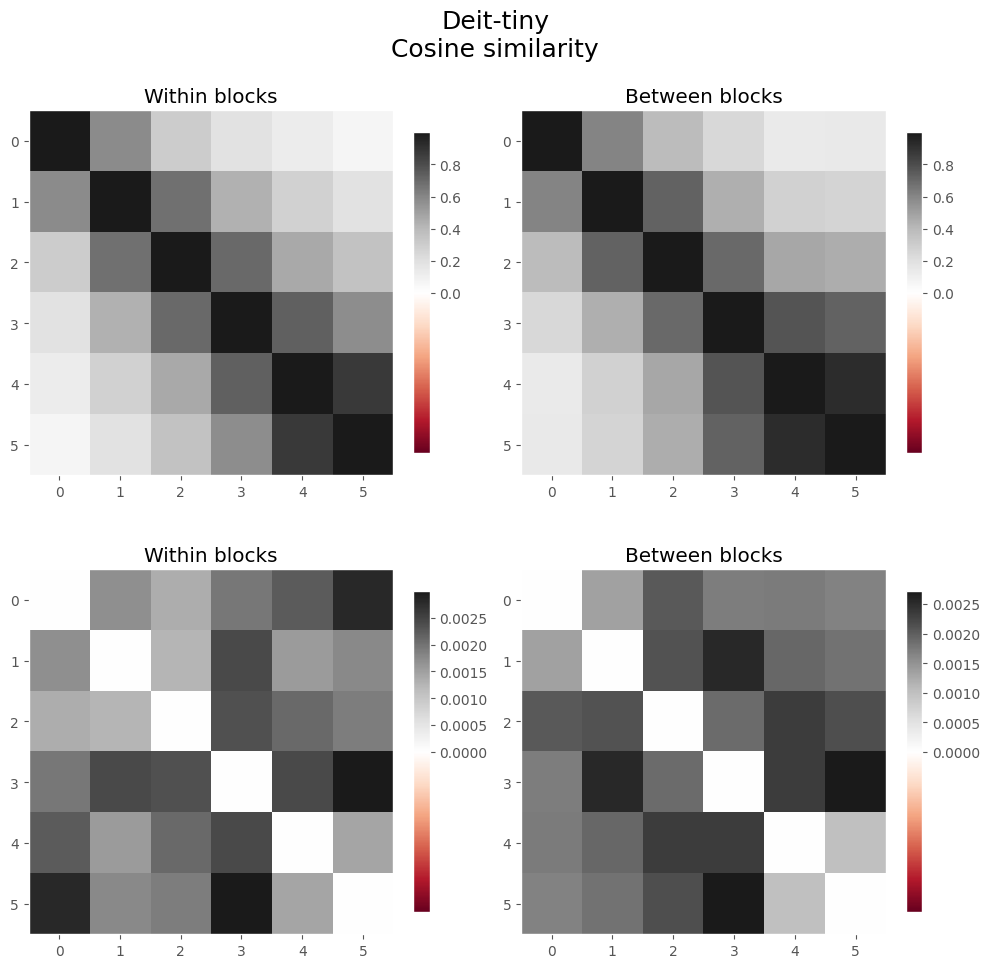

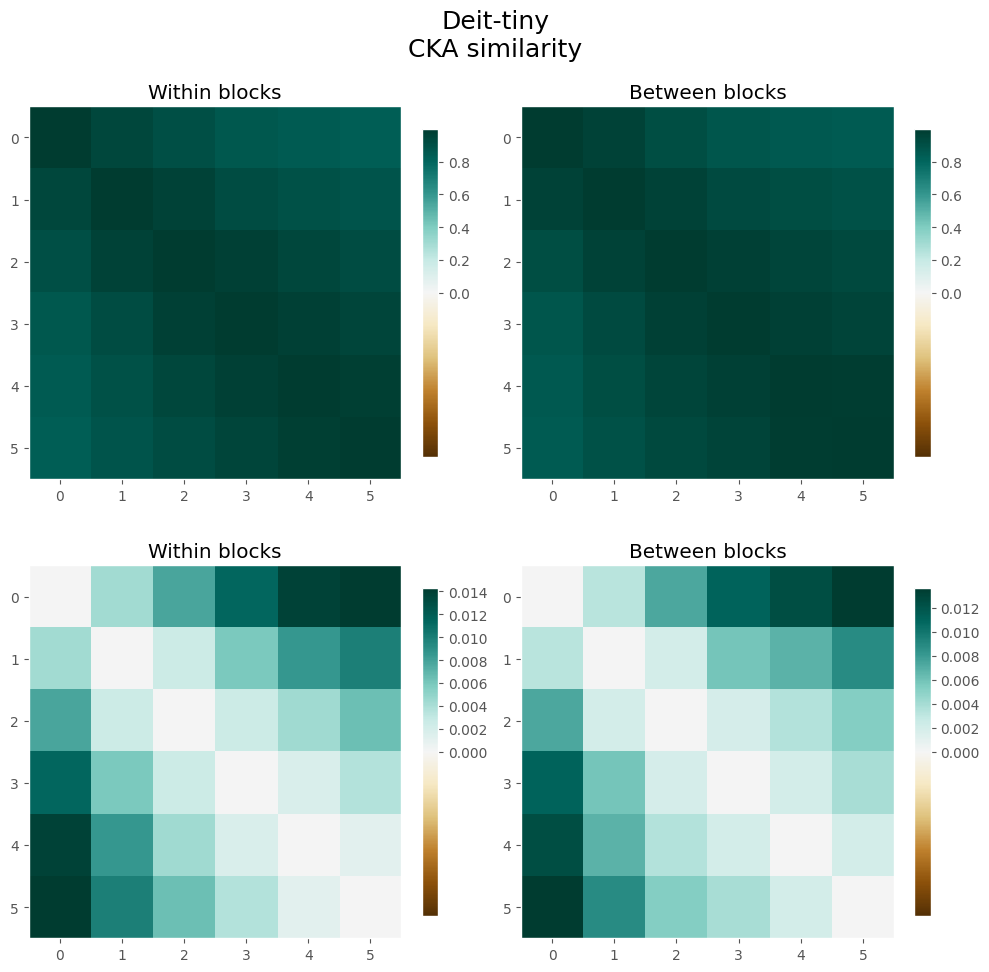

In [17]:
# DeiT experiments
experiments = {
    'deit-tiny': EXP_PATH / "vision/deit-tiny_within=False_['cosine-similarity', 'cka-similarity']_results.pth",
}
# Plot similarity matrices for large model
plot_similarity_matrices(experiments)

## Block Inference scores (pruning)

In [16]:
import numpy as np

def plot_block_inference(experiments, ax, res_per_exp=1):
    assert res_per_exp <= 3
    color_idx = -1
    start_layer_idx = 2
    for exp_name, exp_path in experiments.items():
        results = torch.load(exp_path)
        
        bi_scores = torch.vstack(results['all-block-inferences'])
        n_samples, n_layers = bi_scores.shape
        color_idx += 1

        ax.plot(range(n_layers), bi_scores.mean(dim=0), label=exp_name, linestyle='-' if color_idx % res_per_exp == 0 else '--' if color_idx % res_per_exp == 1 else '-.', color=f'C{color_idx // res_per_exp}')
        ax.fill_between(range(n_layers), bi_scores.quantile(0.05, dim=0), bi_scores.quantile(0.95, dim=0), alpha=0.3, color=f'C{color_idx // res_per_exp}')

    ax.set_xticks(range(n_layers), [f'$\ell={i}$' for i in range(start_layer_idx, n_layers+start_layer_idx)])
    ax.set(xlabel='Layer index', ylabel='Block Inference score [$\mu$ and 90% CI]')
    ax.legend()
    return ax

In [4]:
experiments = {
    'deit-tiny': EXP_PATH / "vision/deit-tiny_within=False_['cosine-similarity', 'cka-similarity']_results.pth",
    # 'deit-small': EXP_PATH / "vision/deit-small_within=False_['block-inference']_results.pth",
    # 'deit-base': EXP_PATH / "vision/deit-base_within=False_['block-inference']_results.pth",
}

for exp_name, exp_path in experiments.items():
    results = torch.load(exp_path)

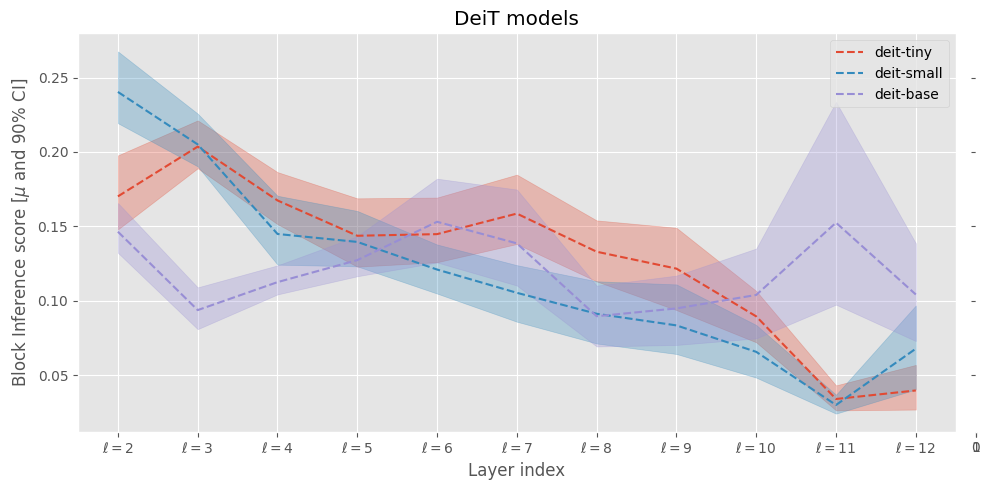

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [1, 0]}, sharey=True)

# Small audio models
experiments = {
    'deit-tiny': EXP_PATH / "vision/deit-tiny_within=False_['block-inference']_results.pth",
    'deit-small': EXP_PATH / "vision/deit-small_within=False_['block-inference']_results.pth",
    'deit-base': EXP_PATH / "vision/deit-base_within=False_['block-inference']_results.pth",
}
# Plot block inference scores
plot_block_inference(experiments, axs[0], res_per_exp=1)
axs[0].set_title('DeiT models')

plt.tight_layout()
plt.show()